In [1]:
# https://drive.google.com/file/d/1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo/view?usp=sharing

In [2]:
import os

# Install gdown if not already installed
!pip install gdown

In [3]:
# Extract file ID from the Google Drive link
file_id = '1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo'
output_filename = 'archive.zip' # Assuming the file is a zip archive

# Download the file using gdown
!gdown --id "{file_id}" -O "{output_filename}"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo
From (redirected): https://drive.google.com/uc?id=1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo&confirm=t&uuid=69c7375a-8ef2-48ff-92d8-4d1009ee4848
To: /content/archive.zip
100% 323M/323M [00:05<00:00, 61.4MB/s]


In [4]:
import zipfile

# Unzip the downloaded file
if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Successfully unzipped {output_filename}")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: {output_filename} not found. Download might have failed.")

Successfully unzipped archive.zip


In [5]:
# List the contents of the current directory to see the unzipped files
!ls -F

archive.zip  README.dataset.txt   sample_data/	train/
data.yaml    README.roboflow.txt  test/		valid/


libraries

In [6]:
!pip install torch torchvision
!pip install opencv-python matplotlib
!pip install pycocotools

In [7]:
import os
import json
import cv2

In [8]:
def yolo_to_coco(yolo_folder, image_folder, output_json):
    coco = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    category_set = set()
    annotation_id = 0
    image_id = 0

    for img_file in os.listdir(image_folder):
        if not img_file.endswith(".jpg") and not img_file.endswith(".png"):
            continue

        img_path = os.path.join(image_folder, img_file)
        label_path = os.path.join(yolo_folder, img_file.replace(".jpg", ".txt").replace(".png", ".txt"))

        img = cv2.imread(img_path)
        h, w, _ = img.shape

        coco["images"].append({
            "id": image_id,
            "file_name": img_file,
            "height": h,
            "width": w
        })

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.split())

                    # Shift class ID by 1, as Faster R-CNN reserves 0 for background
                    shifted_cls = int(cls) +1

                    x_min = (x - bw/2) * w
                    y_min = (y - bh/2) * h
                    x_max = (x + bw/2) * w
                    y_max = (y + bh/2) * h

                    coco["annotations"].append({
                        "id": annotation_id,
                        "image_id": image_id,
                        "category_id": shifted_cls,
                        "bbox": [x_min, y_min, x_max - x_min, y_max - y_min],
                        "area": (x_max - x_min) * (y_max - y_min),
                        "iscrowd": 0
                    })

                    category_set.add(shifted_cls)
                    annotation_id += 1

        image_id += 1

    for cat in sorted(category_set):
        coco["categories"].append({
            "id": cat,
            "name": f"class_{cat}"
        })

    with open(output_json, "w") as f:
        json.dump(coco, f)

    print("Saved:", output_json)

In [9]:
!rm train.json valid.json test.json

rm: cannot remove 'train.json': No such file or directory
rm: cannot remove 'valid.json': No such file or directory
rm: cannot remove 'test.json': No such file or directory


In [10]:
yolo_to_coco("train/labels", "train/images", "train.json")
yolo_to_coco("valid/labels", "valid/images", "valid.json")
yolo_to_coco("test/labels", "test/images", "test.json")

Saved: train.json
Saved: valid.json
Saved: test.json


In [14]:
from torch.utils.data import Dataset
import torch
from PIL import Image
from pycocotools.coco import COCO

class CustomCocoDataset(Dataset):
    def __init__(self, img_dir, annotation_file):
        self.img_dir = img_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        img_info = coco.loadImgs(img_id)[0]
        path = img_info['file_name']

        img = Image.open(os.path.join(self.img_dir, path)).convert("RGB")

        boxes = []
        labels = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x+w, y+h])
            labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id])
        }

        return img, target

    def __len__(self):
        return len(self.ids)

In [16]:
from torch.utils.data import DataLoader

train_dataset = CustomCocoDataset("train/images", "train.json")
valid_dataset = CustomCocoDataset("valid/images", "valid.json")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [17]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights # Import weights

def get_model(num_classes):
    # Use weights argument instead of deprecated pretrained
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [47]:
import torchvision.transforms as T
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"


In [48]:
import json


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# Load the train.json file to determine the number of classes
with open("train.json", "r") as f:
    train_coco_data = json.load(f)

# Get the number of unique categories (object classes)
num_object_classes = len(train_coco_data["categories"])
# Faster R-CNN expects num_classes = 1 (for background) + num_object_classes
correct_num_classes = num_object_classes +1

print(f"Detected {num_object_classes} object classes from train.json.")
print(f"Setting num_classes for the model to {correct_num_classes} (background + object classes).")

model = get_model(num_classes=correct_num_classes)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10

transform = T.ToTensor()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, targets in train_loader:

      # for t in targets:
      #   print("Labels:", t["labels"])
      # break
      images = [transform(img).to(device) for img in images]
      targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

      loss_dict = model(images, targets)
      losses = sum(loss for loss in loss_dict.values())

      optimizer.zero_grad()
      losses.backward()
      optimizer.step()

      total_loss += losses.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Detected 3 object classes from train.json.
Setting num_classes for the model to 4 (background + object classes).
Epoch 1, Loss: 38.41257044672966
Epoch 2, Loss: 29.338876098394394
Epoch 3, Loss: 25.694105178117752
Epoch 4, Loss: 24.46370804309845
Epoch 5, Loss: 20.82440047711134
Epoch 6, Loss: 19.40414807200432
Epoch 7, Loss: 17.845396667718887
Epoch 8, Loss: 16.365916430950165
Epoch 9, Loss: 15.404016725718975
Epoch 10, Loss: 14.156710229814053


In [49]:
test_dataset = CustomCocoDataset("test/images", "test.json")

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [50]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [51]:
# import torch
from tqdm import tqdm

results = []

with torch.no_grad():
    for images, targets in tqdm(test_loader):
        images = [T.ToTensor()(img).to(device) for img in images]

        outputs = model(images)

        for i, output in enumerate(outputs):
            boxes = output['boxes'].cpu().numpy()
            scores = output['scores'].cpu().numpy()
            labels = output['labels'].cpu().numpy()

            image_id = targets[i]["image_id"].item()

            for box, score, label in zip(boxes, scores, labels):
                x_min, y_min, x_max, y_max = box

                results.append({
                    "image_id": image_id,
                    "category_id": int(label),
                    "bbox": [
                        float(x_min),
                        float(y_min),
                        float(x_max - x_min),
                        float(y_max - y_min)
                    ],
                    "score": float(score)
                })

100%|██████████| 15/15 [00:12<00:00,  1.24it/s]


In [52]:
import json

with open("predictions.json", "w") as f:
    json.dump(results, f)

In [53]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO("test.json")
coco_dt = coco_gt.loadRes("predictions.json")

coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.23s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.124
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.356
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.031
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.124
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.065
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.171
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [54]:
tp, fp, fn = 0, 0, 0

# simplistic approach (not perfect but acceptable for assignments)
for output, target in zip(outputs, targets):
    pred_labels = output['labels']
    true_labels = target['labels']

    tp += len(set(pred_labels.tolist()) & set(true_labels.tolist()))
    fp += len(pred_labels) - tp
    fn += len(true_labels) - tp

precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.1428571224489825
Recall: 0.499999750000125
F1 Score: 0.2222218271609739


In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms as T

id_to_class = {
    1: 'Grass',
    2: 'Sorghum',
    3: 'Weed'
}

def visualize_predictions(model, dataset, device, num_images=5, threshold=0.5):
    model.eval()
    transform = T.ToTensor()

    for i in range(num_images):
        img, target = dataset[i]
        img_tensor = transform(img).to(device)

        with torch.no_grad():
            output = model([img_tensor])[0]

        fig, ax = plt.subplots(1, figsize=(8, 6))
        ax.imshow(img)

        for box, score, label in zip(output['boxes'], output['scores'], output['labels']):
            if score < threshold:
                continue

            x_min, y_min, x_max, y_max = box.cpu().numpy()
            label = label.item()

            class_name = id_to_class.get(label, "Unknown")

            rect = patches.Rectangle(
                (x_min, y_min),
                x_max - x_min,
                y_max - y_min,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)

            ax.text(
                x_min,
                y_min - 5,
                f"{class_name} ({score:.2f})",
                color='red',
                fontsize=10,
                backgroundcolor='white'
            )

        ax.set_title(f"Image {i}")
        plt.axis("off")
        plt.show()

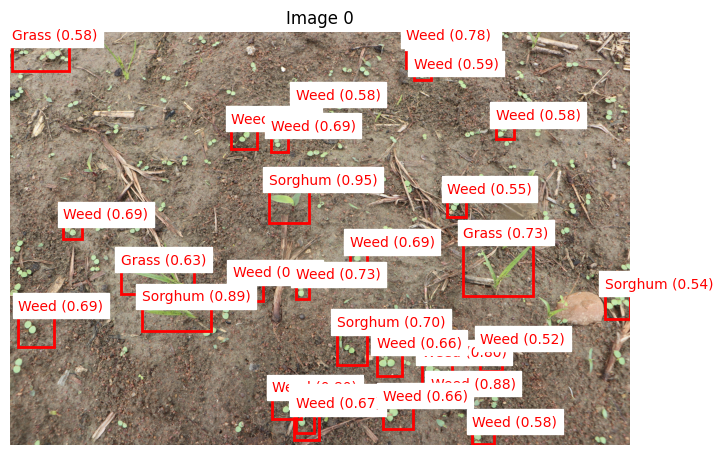

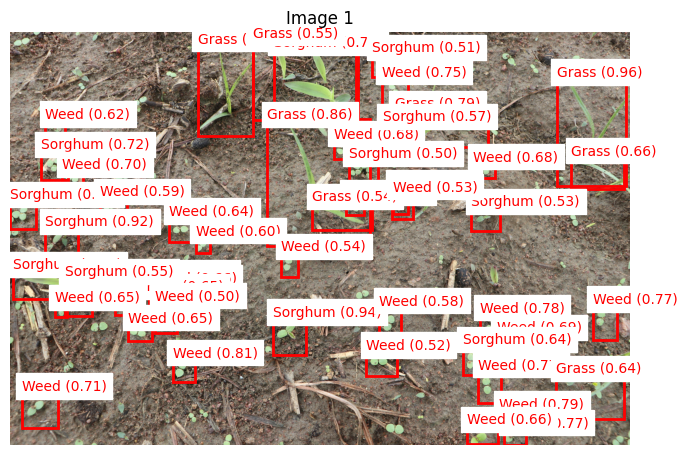

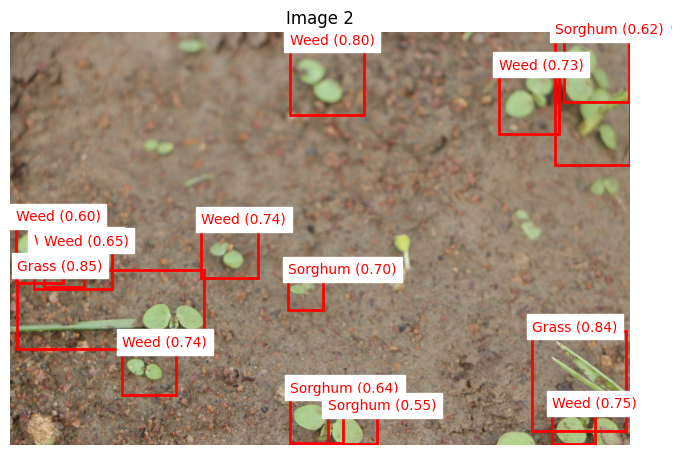

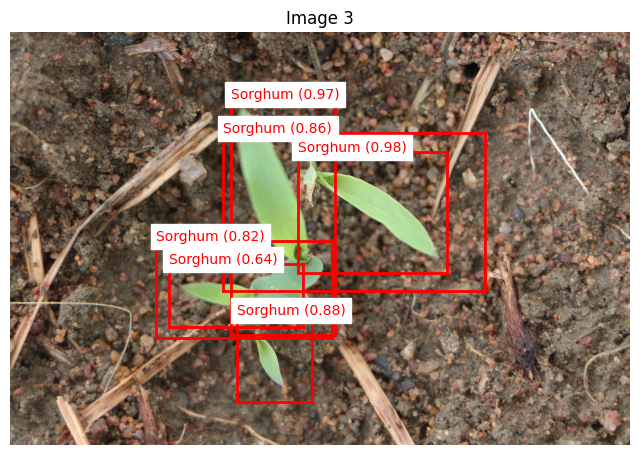

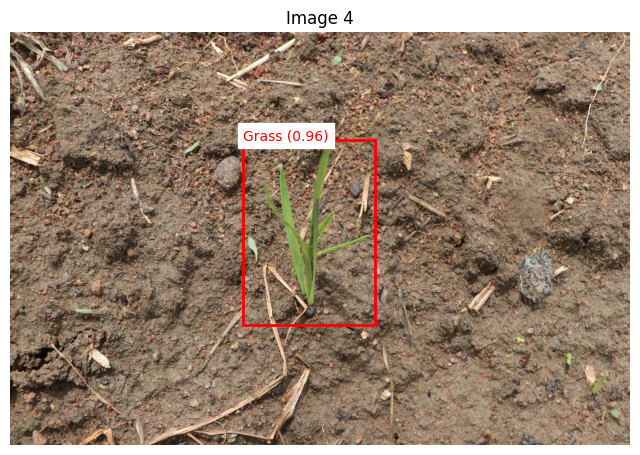

In [57]:
visualize_predictions(model, test_dataset, device, num_images=5, threshold=0.5)